In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_excel("DF3_Magnitude.xlsx")

In [3]:
df.head()

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_max,M8_mean,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Condition,Level,FileName
0,0.000263,0.000752,0.000502,0.000067,4.551717e-09,0.000506,0.000502,0.000166,0.000470,0.000317,...,0.000339,0.000219,0.00003,9.185403e-10,0.000221,0.000219,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1
1,0.000239,0.000744,0.000500,0.000067,4.554403e-09,0.000505,0.000500,0.000163,0.000482,0.000317,...,0.000342,0.000220,0.00003,9.203908e-10,0.000222,0.000220,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP2
2,0.000256,0.000755,0.000503,0.000067,4.524080e-09,0.000507,0.000503,0.000156,0.000476,0.000318,...,0.000344,0.000213,0.00003,9.204369e-10,0.000215,0.000213,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP3
3,0.000257,0.000756,0.000505,0.000067,4.527095e-09,0.000509,0.000505,0.000157,0.000470,0.000316,...,0.000334,0.000215,0.00003,9.161455e-10,0.000217,0.000215,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP4
4,0.000252,0.000755,0.000506,0.000067,4.500827e-09,0.000510,0.000506,0.000155,0.000478,0.000315,...,0.000347,0.000217,0.00003,9.012421e-10,0.000219,0.000217,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP5


In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(273, 60)
Index(['M1_min', 'M1_max', 'M1_mean', 'M1_std', 'M1_var', 'M1_rms', 'M1_mav',
       'M2_min', 'M2_max', 'M2_mean', 'M2_std', 'M2_var', 'M2_rms', 'M2_mav',
       'M3_min', 'M3_max', 'M3_mean', 'M3_std', 'M3_var', 'M3_rms', 'M3_mav',
       'M4_min', 'M4_max', 'M4_mean', 'M4_std', 'M4_var', 'M4_rms', 'M4_mav',
       'M5_min', 'M5_max', 'M5_mean', 'M5_std', 'M5_var', 'M5_rms', 'M5_mav',
       'M6_min', 'M6_max', 'M6_mean', 'M6_std', 'M6_var', 'M6_rms', 'M6_mav',
       'M7_min', 'M7_max', 'M7_mean', 'M7_std', 'M7_var', 'M7_rms', 'M7_mav',
       'M8_min', 'M8_max', 'M8_mean', 'M8_std', 'M8_var', 'M8_rms', 'M8_mav',
       'Amplitude', 'Condition', 'Level', 'FileName'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 60 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   M1_min     273 non-null    float64
 1   M1_max     273 non-null    float64
 2   M1_mean    273 non-

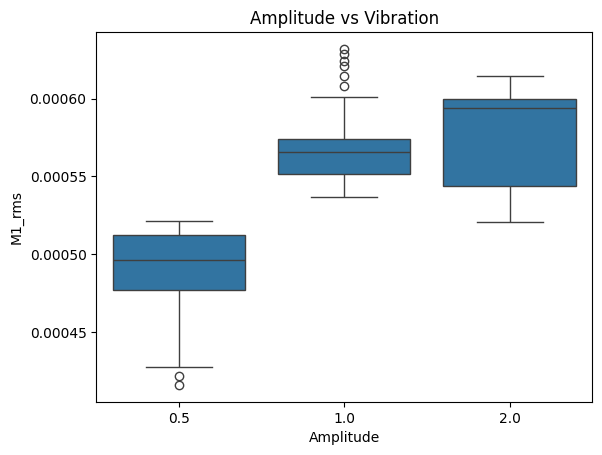

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Amplitude", y="M1_rms", data=df)
plt.title("Amplitude vs Vibration")
plt.show()

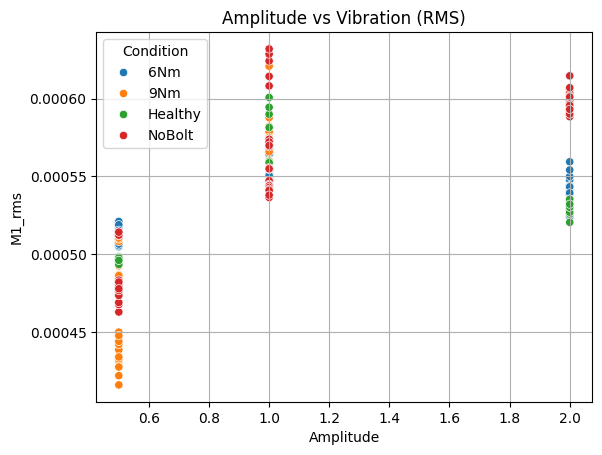

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Amplitude", y="M1_rms", hue="Condition")
plt.title("Amplitude vs Vibration (RMS)")
plt.grid()
plt.show()

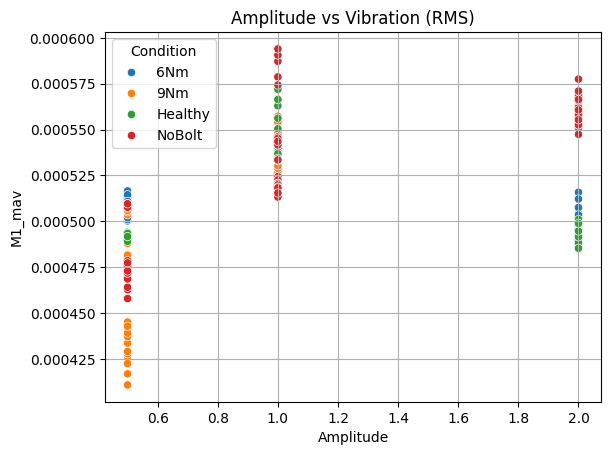

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Amplitude", y="M1_mav", hue="Condition")
plt.title("Amplitude vs Vibration (RMS)")
plt.grid()
plt.show()

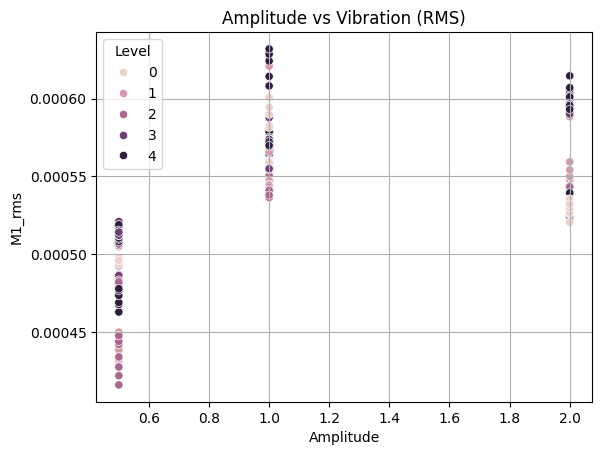

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Amplitude", y="M1_rms", hue="Level")
plt.title("Amplitude vs Vibration (RMS)")
plt.grid()
plt.show()

In [9]:
rms_cols = [col for col in df.columns if "_rms" in col]
df["Avg_RMS"] = df[rms_cols].mean(axis=1)

In [10]:
def to_nm(cond):
    if cond == "Healthy":
        return 12
    elif "9" in cond:
        return 9
    elif "6" in cond:
        return 6
    else:
        return 0

df["Bolt_Nm"] = df["Condition"].apply(to_nm)

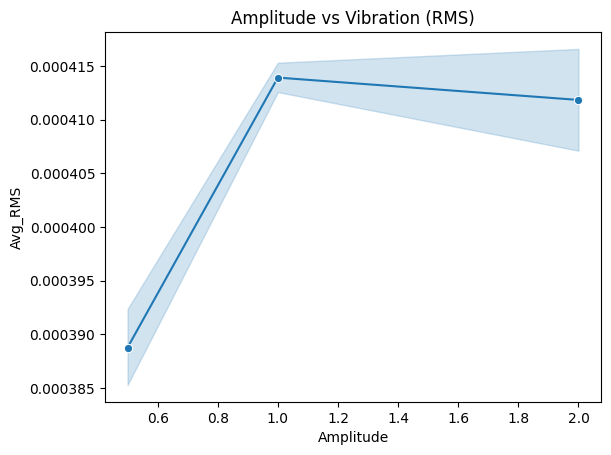

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="Amplitude", y="Avg_RMS", estimator="mean", marker="o")
plt.title("Amplitude vs Vibration (RMS)")
plt.show()

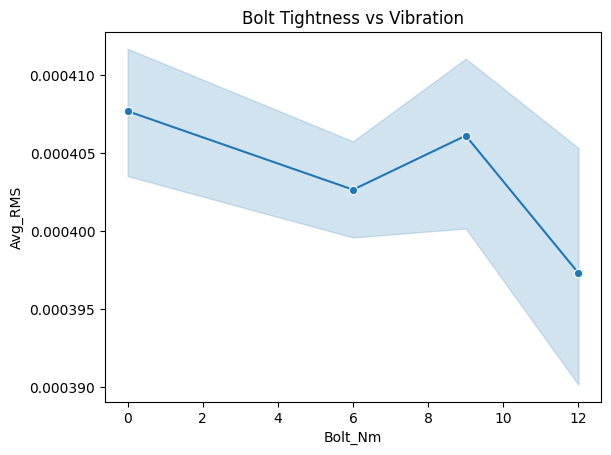

In [12]:
sns.lineplot(data=df, x="Bolt_Nm", y="Avg_RMS", estimator="mean", marker="o")
plt.title("Bolt Tightness vs Vibration")
plt.show()

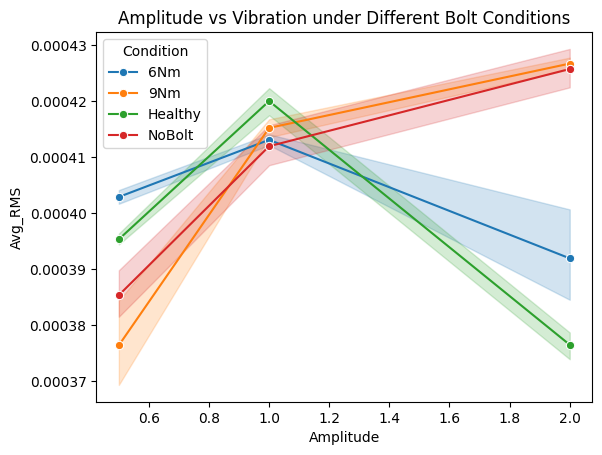

In [13]:
sns.lineplot(data=df, x="Amplitude", y="Avg_RMS", hue="Condition", marker="o")
plt.title("Amplitude vs Vibration under Different Bolt Conditions")
plt.show()

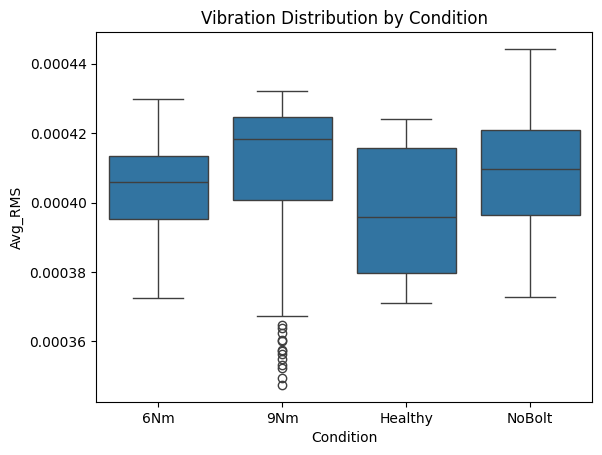

In [14]:
sns.boxplot(x="Condition", y="Avg_RMS", data=df)
plt.title("Vibration Distribution by Condition")
plt.show()

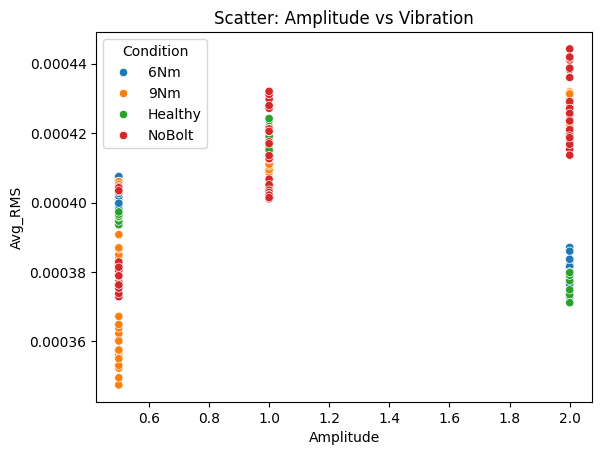

In [15]:
sns.scatterplot(data=df, x="Amplitude", y="Avg_RMS", hue="Condition")
plt.title("Scatter: Amplitude vs Vibration")
plt.show()

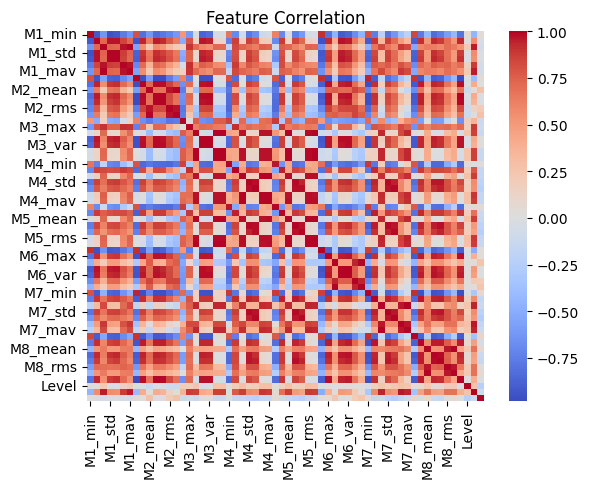

In [16]:
corr = df.corr(numeric_only=True)

import seaborn as sns
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

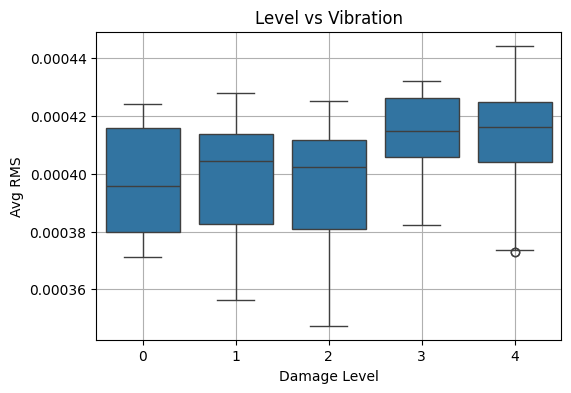

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Level", y="Avg_RMS")

plt.title("Level vs Vibration")
plt.xlabel("Damage Level")
plt.ylabel("Avg RMS")
plt.grid()

plt.show()

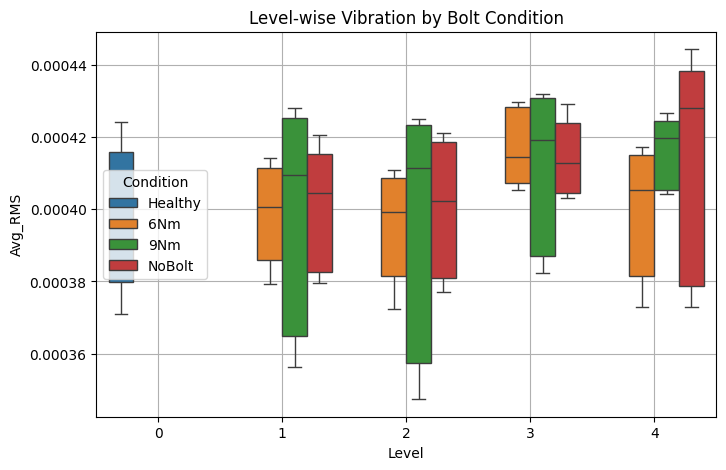

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Level", y="Avg_RMS", hue="Condition")

plt.title("Level-wise Vibration by Bolt Condition")
plt.grid()

plt.show()

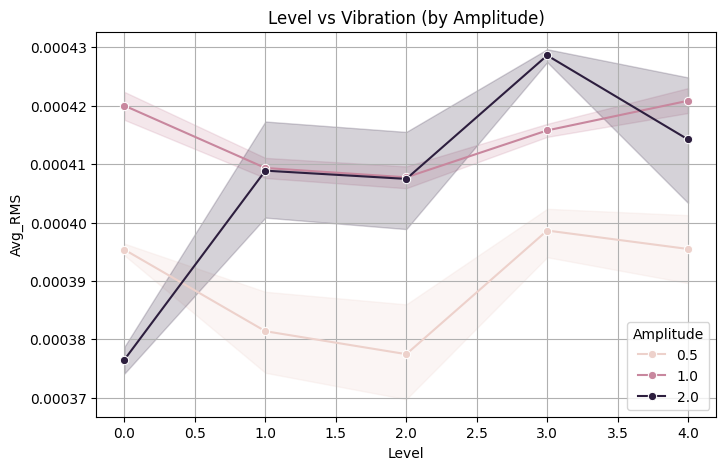

In [19]:
plt.figure(figsize=(8,5))

sns.lineplot(data=df, x="Level", y="Avg_RMS", hue="Amplitude", marker="o")

plt.title("Level vs Vibration (by Amplitude)")
plt.grid()

plt.show()

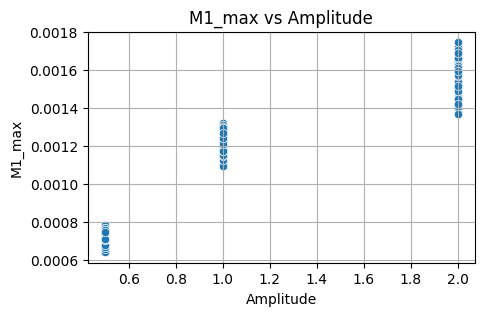

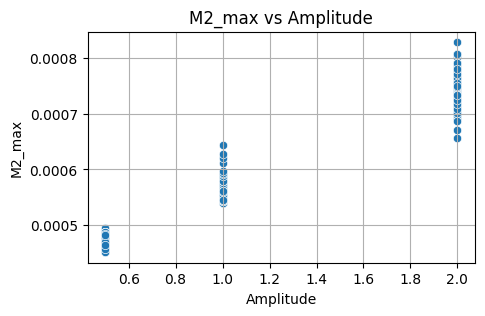

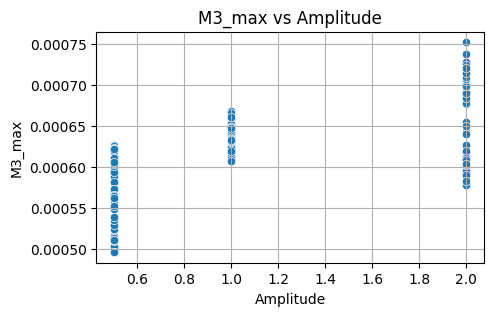

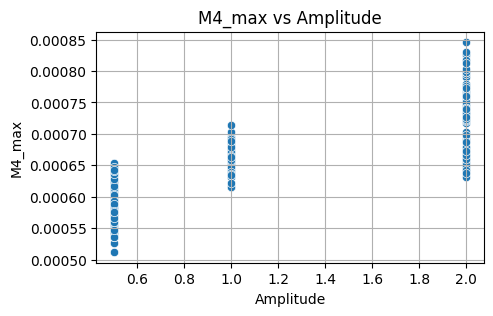

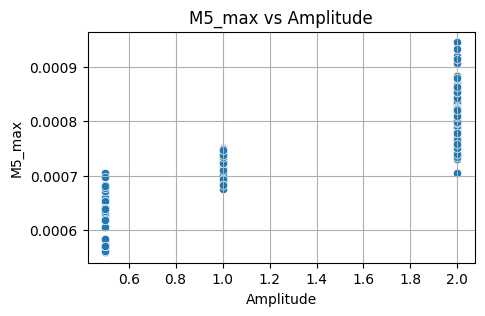

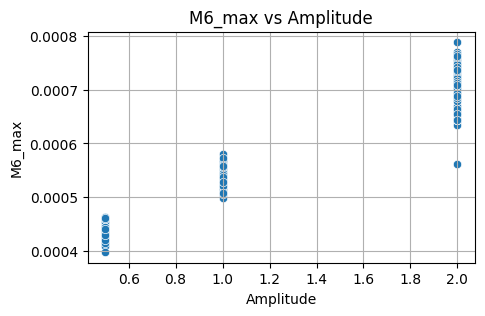

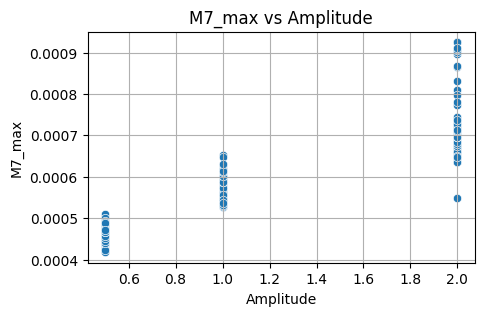

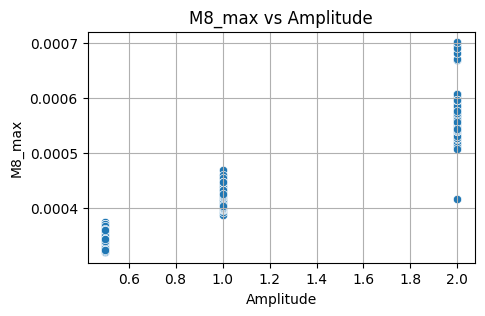

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

max_cols = [col for col in df.columns if "_max" in col]

for col in max_cols:
    plt.figure(figsize=(5,3))
    
    sns.scatterplot(data=df, x="Amplitude", y=col)
    
    plt.title(f"{col} vs Amplitude")
    plt.xlabel("Amplitude")
    plt.ylabel(col)
    plt.grid()
    
    plt.show()

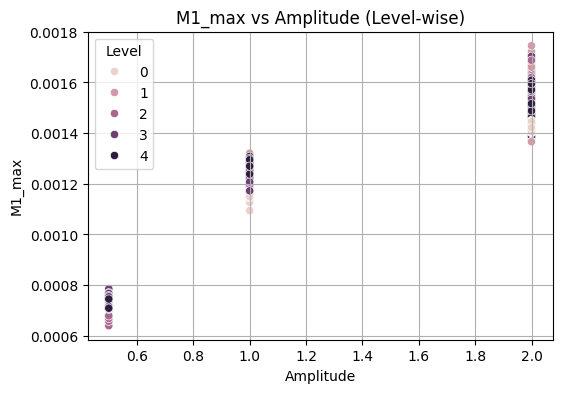

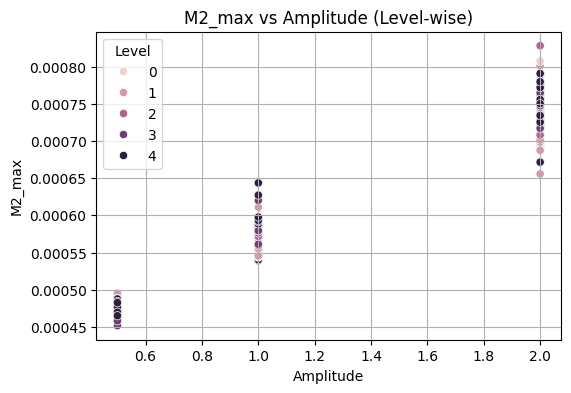

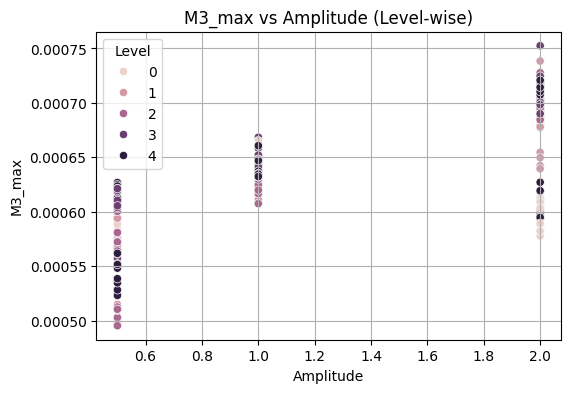

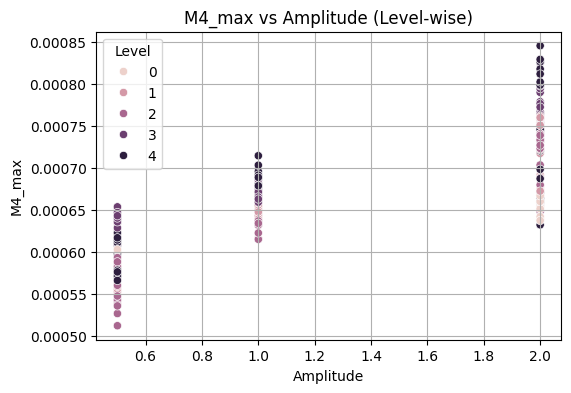

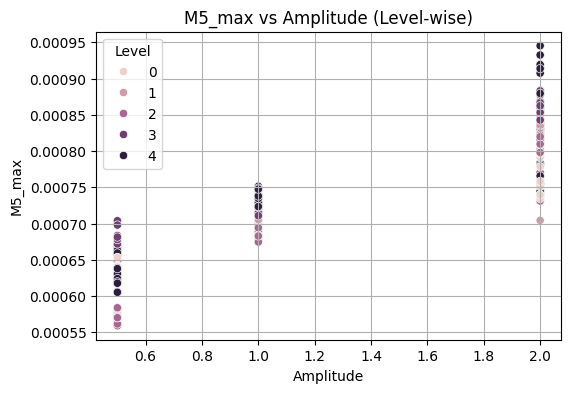

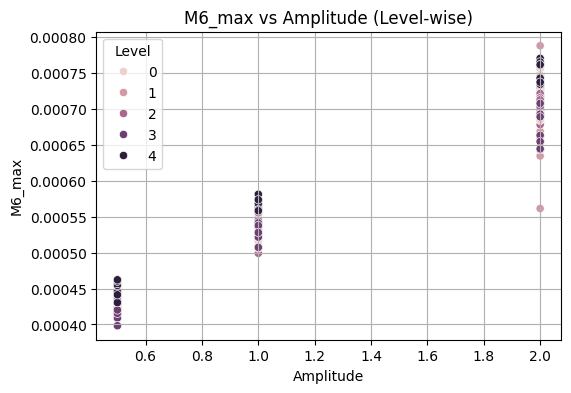

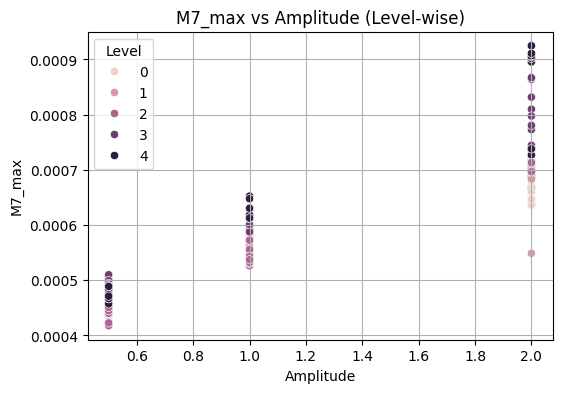

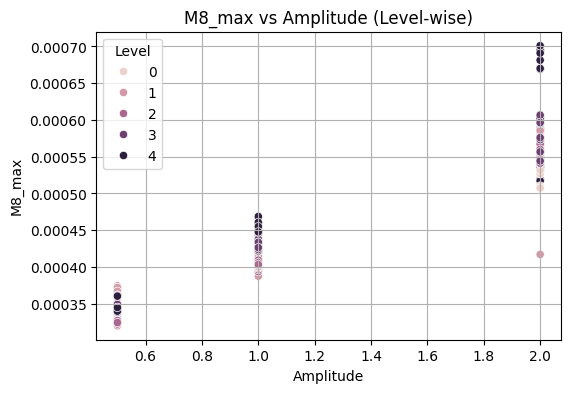

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

max_cols = [col for col in df.columns if "_max" in col]

for col in max_cols:
    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x="Amplitude",
        y=col,
        hue="Level"   # 👈 important change
    )

    plt.title(f"{col} vs Amplitude (Level-wise)")
    plt.xlabel("Amplitude")
    plt.ylabel(col)
    plt.grid()

    plt.show()

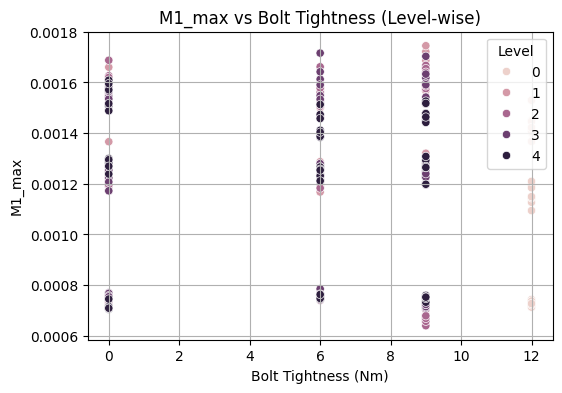

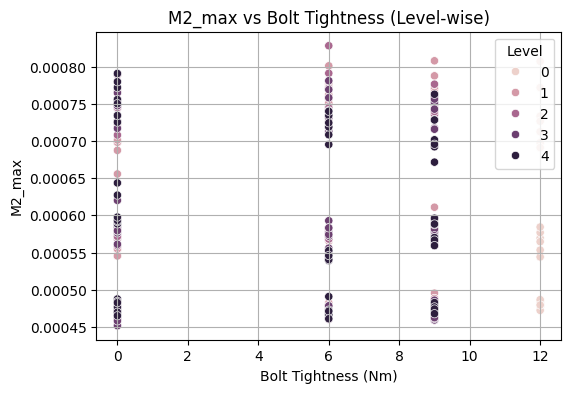

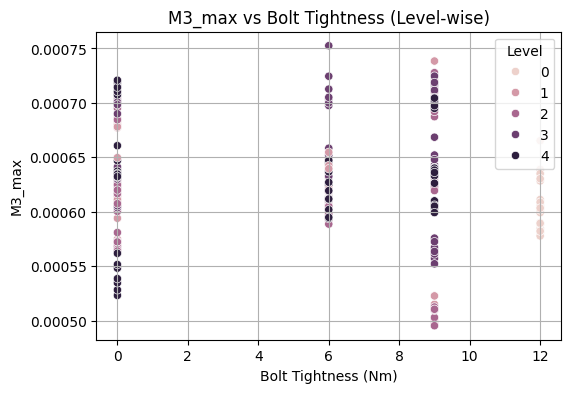

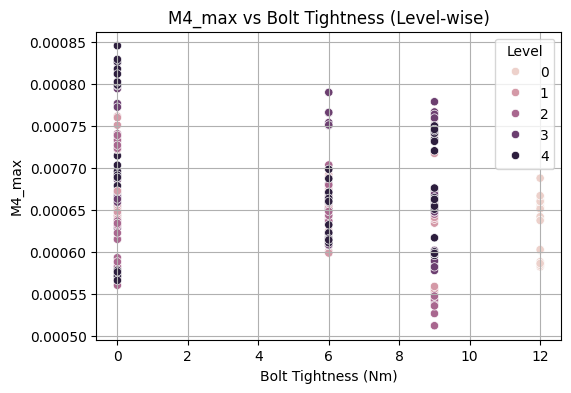

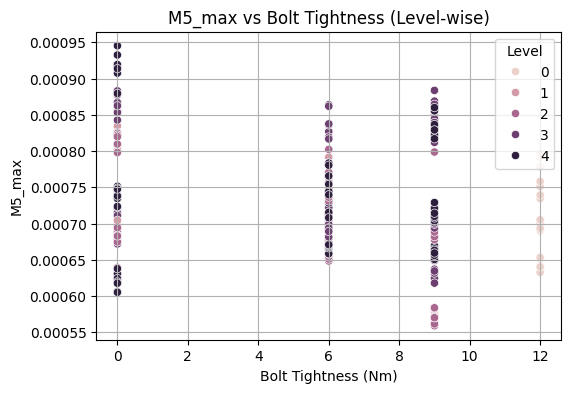

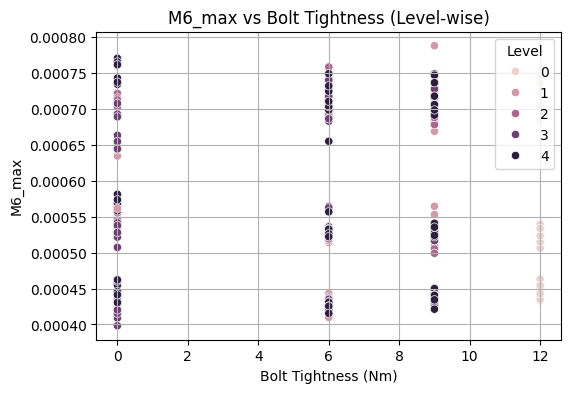

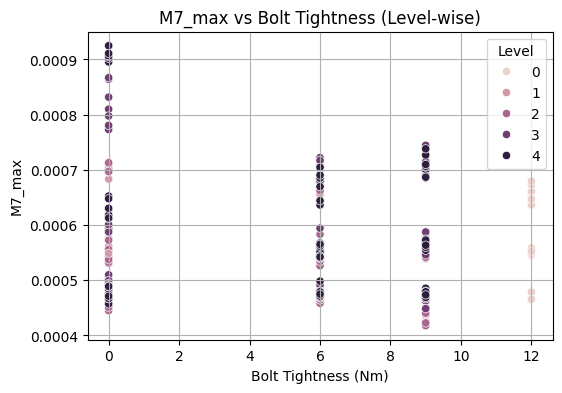

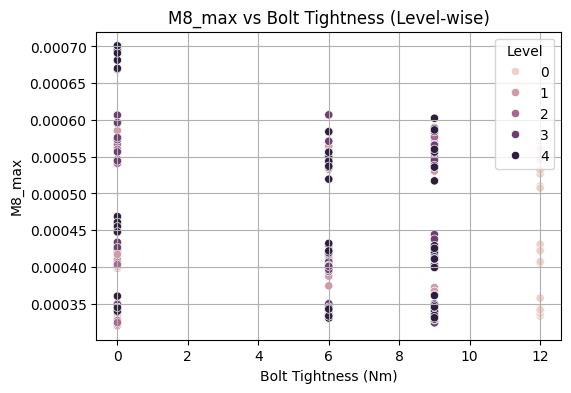

In [22]:
def to_nm(cond):
    if cond == "Healthy":
        return 12
    elif "9" in cond:
        return 9
    elif "6" in cond:
        return 6
    else:
        return 0

df["Bolt_Nm"] = df["Condition"].apply(to_nm)

for col in max_cols:
    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x="Bolt_Nm",
        y=col,
        hue="Level"
    )

    plt.title(f"{col} vs Bolt Tightness (Level-wise)")
    plt.xlabel("Bolt Tightness (Nm)")
    plt.ylabel(col)
    plt.grid()

    plt.show()

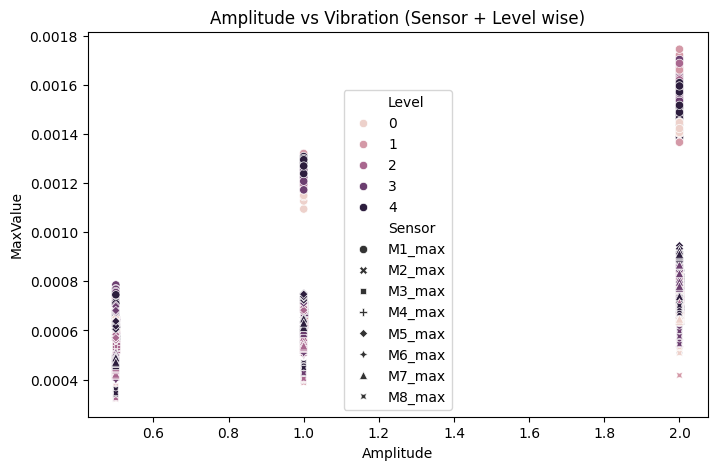

In [23]:
df_melt = df.melt(
    id_vars=["Amplitude", "Level"],
    value_vars=max_cols,
    var_name="Sensor",
    value_name="MaxValue"
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_melt,
    x="Amplitude",
    y="MaxValue",
    hue="Level",
    style="Sensor"
)

plt.title("Amplitude vs Vibration (Sensor + Level wise)")
plt.show()

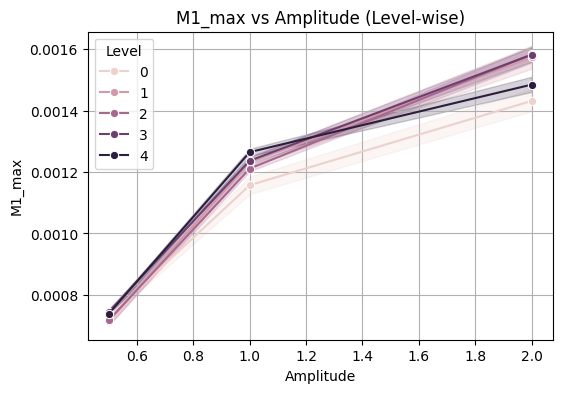

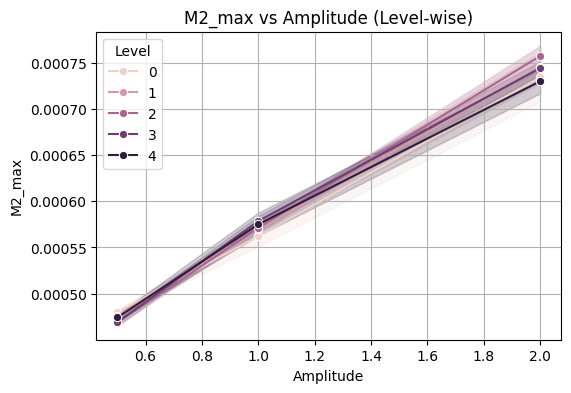

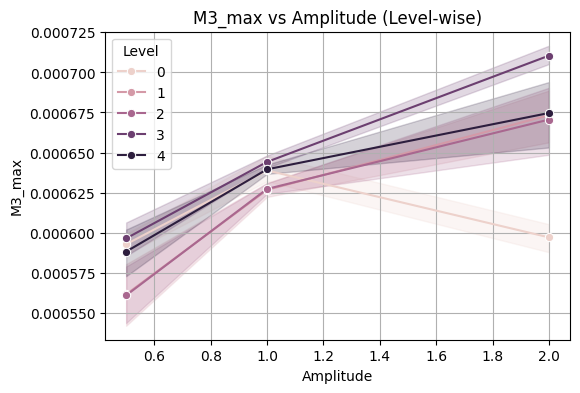

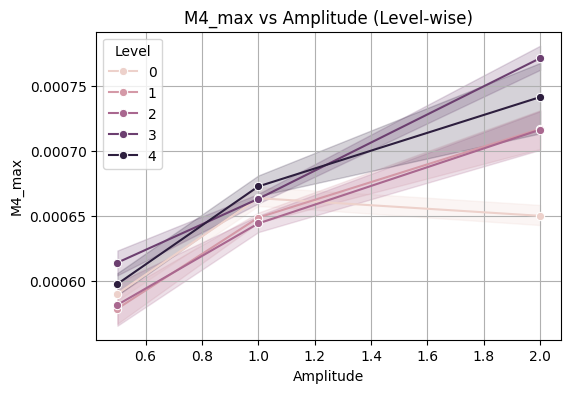

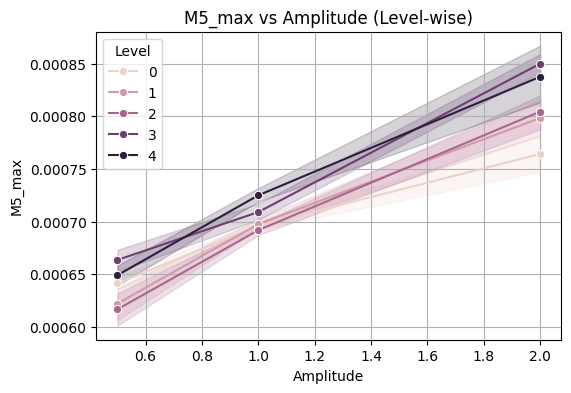

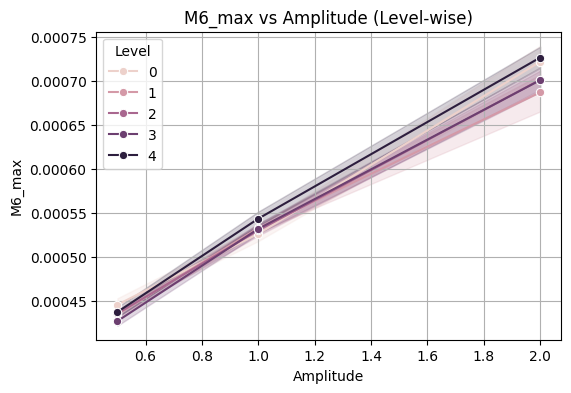

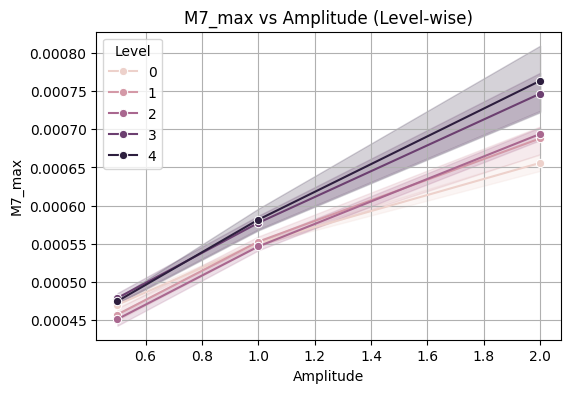

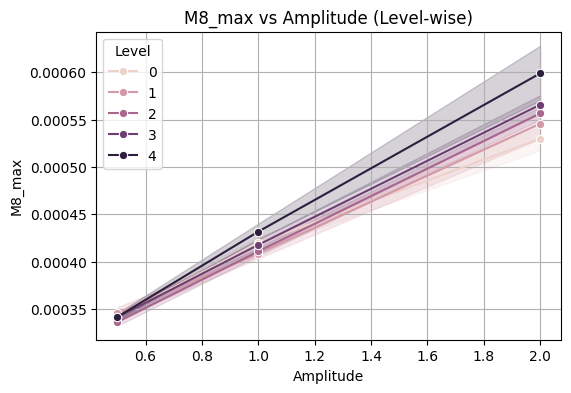

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

max_cols = [col for col in df.columns if "_max" in col]

for col in max_cols:
    plt.figure(figsize=(6,4))

    sns.lineplot(
        data=df,
        x="Amplitude",
        y=col,
        hue="Level",
        marker="o"
    )

    plt.title(f"{col} vs Amplitude (Level-wise)")
    plt.xlabel("Amplitude")
    plt.ylabel(col)
    plt.grid()

    plt.show()

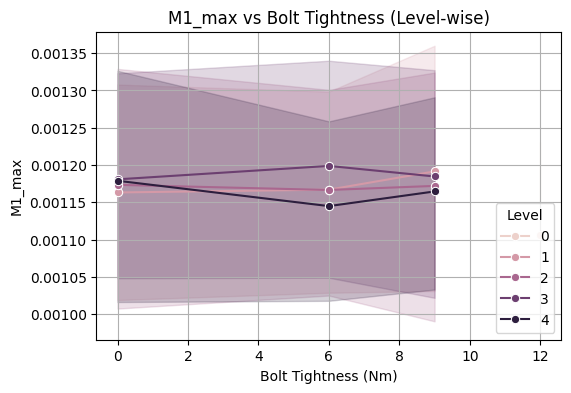

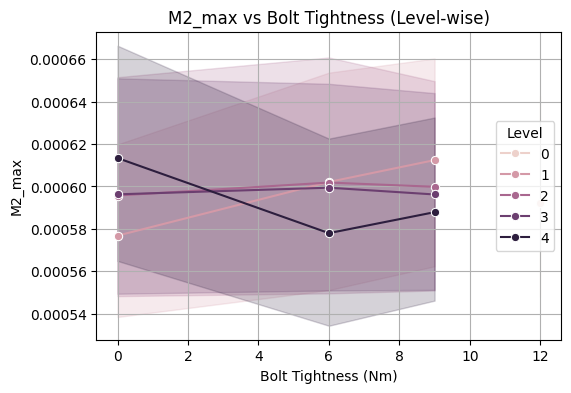

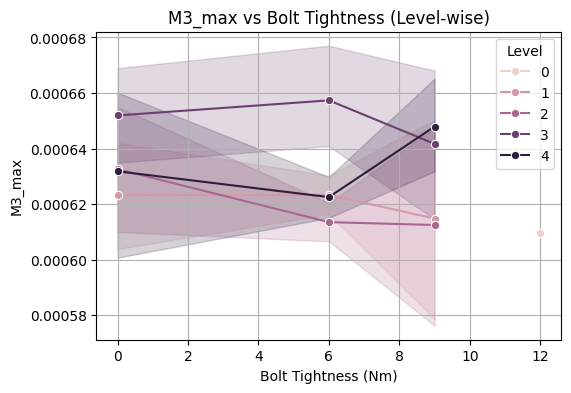

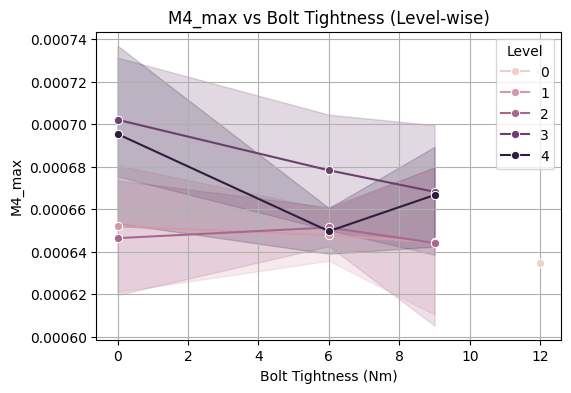

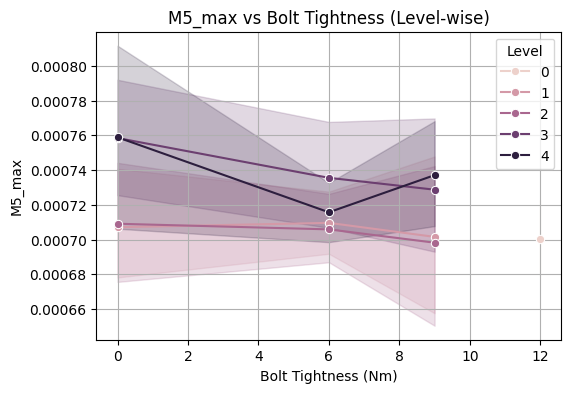

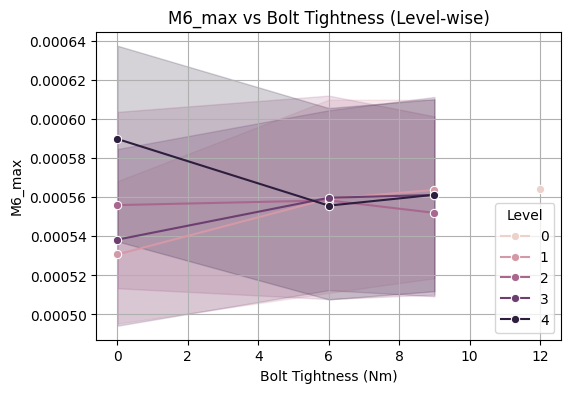

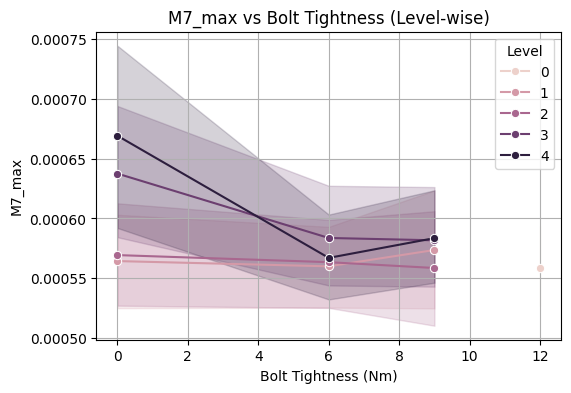

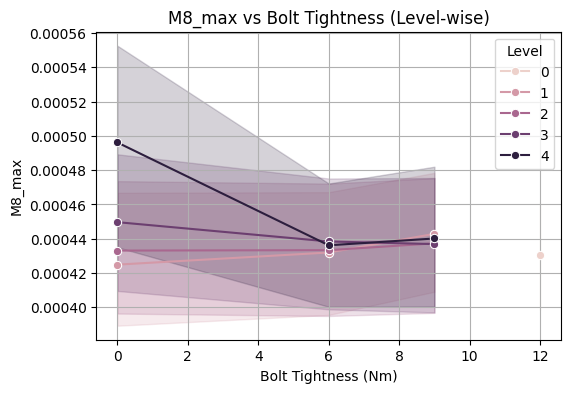

In [25]:
def to_nm(cond):
    if cond == "Healthy":
        return 12
    elif "9" in cond:
        return 9
    elif "6" in cond:
        return 6
    else:
        return 0

df["Bolt_Nm"] = df["Condition"].apply(to_nm)

for col in max_cols:
    plt.figure(figsize=(6,4))

    sns.lineplot(
        data=df,
        x="Bolt_Nm",
        y=col,
        hue="Level",
        marker="o"
    )

    plt.title(f"{col} vs Bolt Tightness (Level-wise)")
    plt.xlabel("Bolt Tightness (Nm)")
    plt.ylabel(col)
    plt.grid()

    plt.show()

In [26]:
rms_cols = [col for col in df.columns if "_rms" in col]

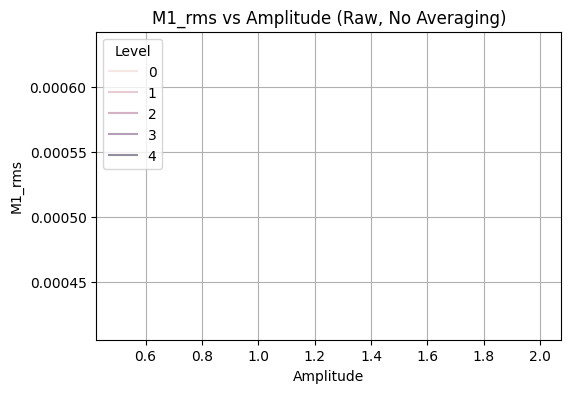

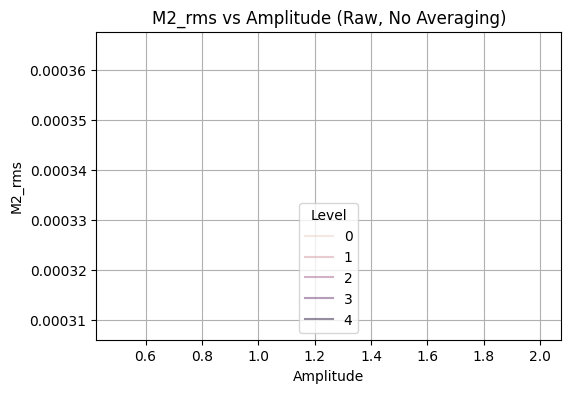

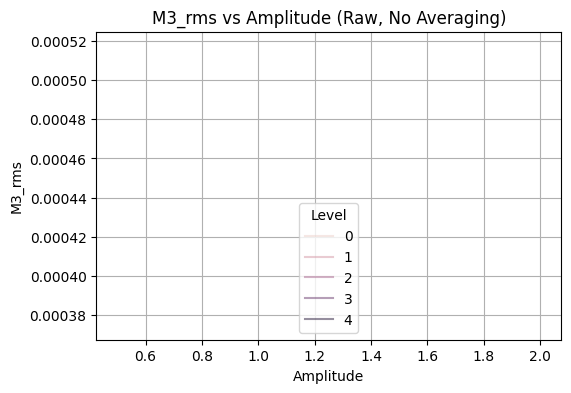

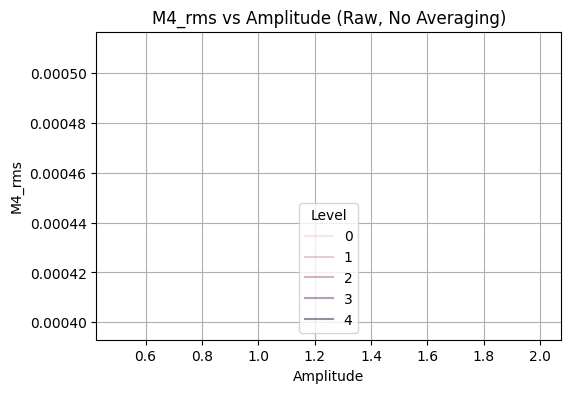

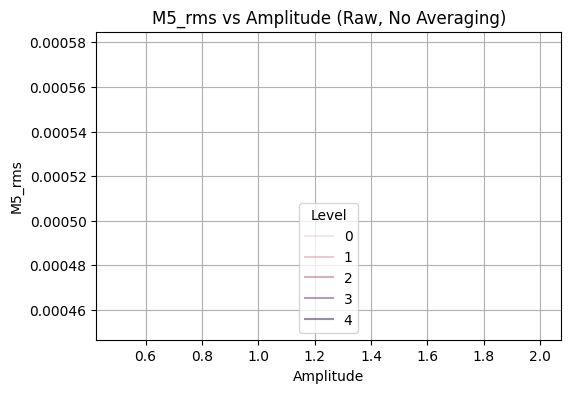

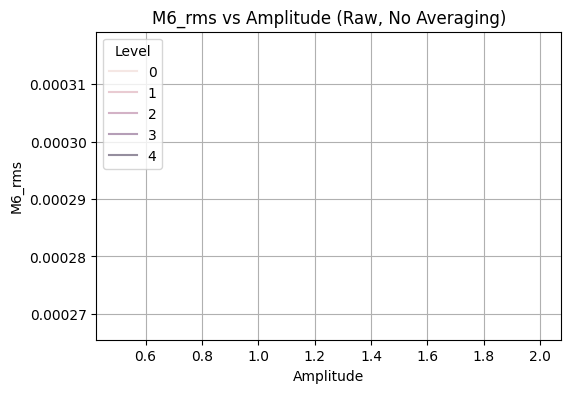

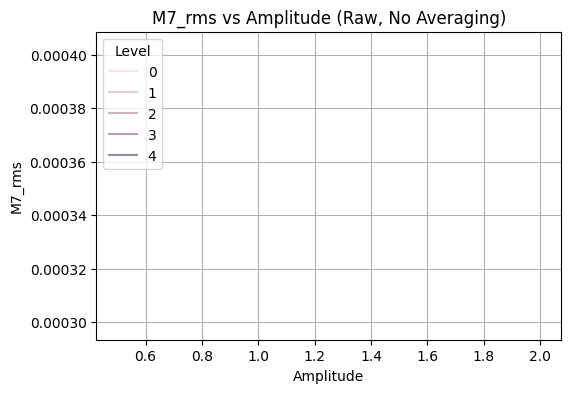

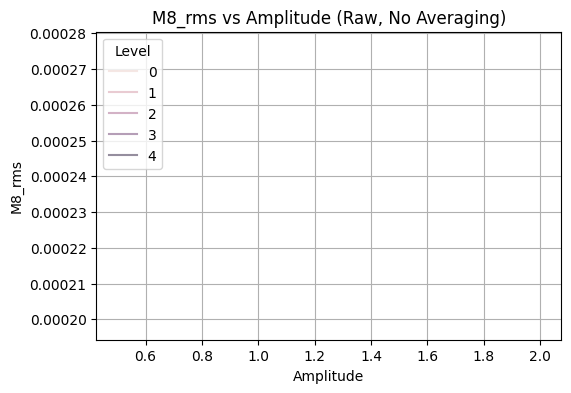

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in rms_cols:
    plt.figure(figsize=(6,4))

    sns.lineplot(
        data=df,
        x="Amplitude",
        y=col,
        hue="Level",
        estimator=None,   # 🔥 IMPORTANT (no averaging)
        units="FileName", # each experiment separate line
        alpha=0.5
    )

    plt.title(f"{col} vs Amplitude (Raw, No Averaging)")
    plt.xlabel("Amplitude")
    plt.ylabel(col)
    plt.grid()

    plt.show()

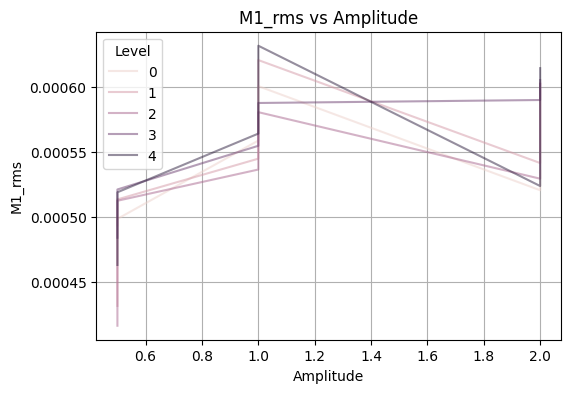

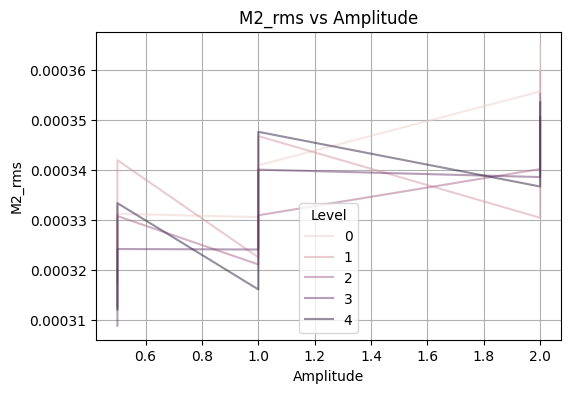

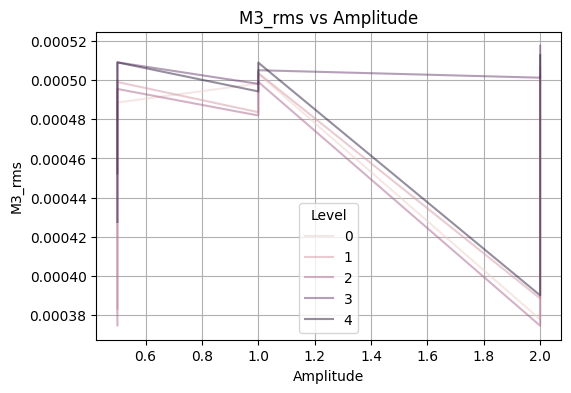

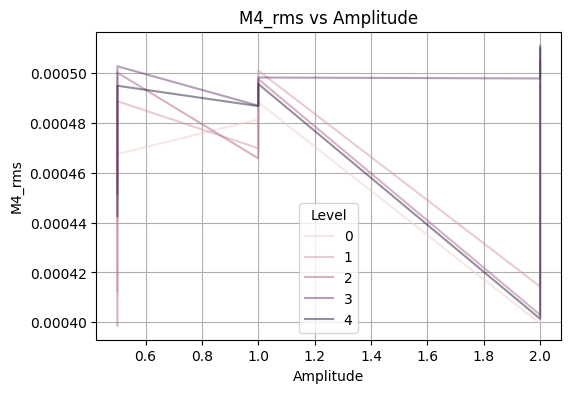

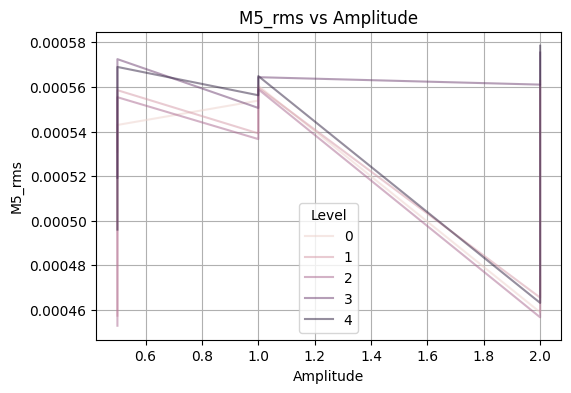

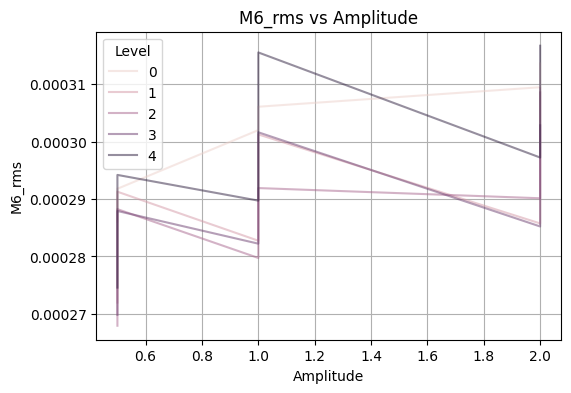

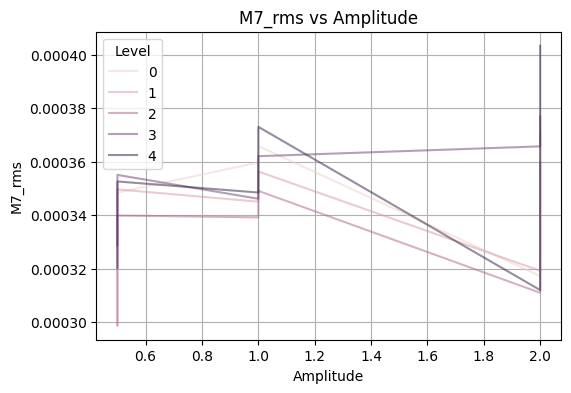

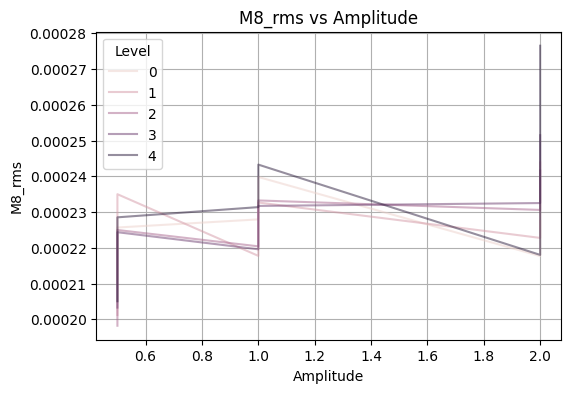

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
df["Amplitude"] = pd.to_numeric(df["Amplitude"], errors="coerce")

for col in rms_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop NaN
df = df.dropna(subset=["Amplitude"] + rms_cols)

# Sort
df = df.sort_values(by="Amplitude")

# Plot
for col in rms_cols:
    plt.figure(figsize=(6,4))

    sns.lineplot(
        data=df,
        x="Amplitude",
        y=col,
        hue="Level",
        estimator=None,
        alpha=0.5
    )

    plt.title(f"{col} vs Amplitude")
    plt.grid()

    plt.show()

In [29]:
df.head()

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Condition,Level,FileName,Avg_RMS,Bolt_Nm
0,0.000263,0.000752,0.000502,0.000067,4.551717e-09,0.000506,0.000502,0.000166,0.000470,0.000317,...,0.00003,9.185403e-10,0.000221,0.000219,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,0.000402,6
1,0.000239,0.000744,0.000500,0.000067,4.554403e-09,0.000505,0.000500,0.000163,0.000482,0.000317,...,0.00003,9.203908e-10,0.000222,0.000220,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP2,0.000401,6
2,0.000256,0.000755,0.000503,0.000067,4.524080e-09,0.000507,0.000503,0.000156,0.000476,0.000318,...,0.00003,9.204369e-10,0.000215,0.000213,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP3,0.000400,6
3,0.000257,0.000756,0.000505,0.000067,4.527095e-09,0.000509,0.000505,0.000157,0.000470,0.000316,...,0.00003,9.161455e-10,0.000217,0.000215,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP4,0.000399,6
4,0.000252,0.000755,0.000506,0.000067,4.500827e-09,0.000510,0.000506,0.000155,0.000478,0.000315,...,0.00003,9.012421e-10,0.000219,0.000217,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP5,0.000400,6


In [70]:
df1 = df[
    ((df["Level"].isin([1,0]))) &
    (df["Amplitude"].round(2) == 0.5)
]

In [71]:
print(df["Amplitude"].unique())
print(df["Level"].unique())

[0.5 1.  2. ]
[1 2 3 4 0]


In [66]:
print(df.groupby(["Amplitude", "Level"]).size())

Amplitude  Level
0.5        0         7
           1        21
           2        21
           3        21
           4        21
1.0        0         7
           1        21
           2        21
           3        21
           4        21
2.0        0         7
           1        21
           2        21
           3        21
           4        21
dtype: int64


In [67]:
df1

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Condition,Level,FileName,Avg_RMS,Bolt_Nm
0,0.000263,0.000752,0.000502,0.000067,4.551717e-09,0.000506,0.000502,0.000166,0.000470,0.000317,...,0.000030,9.185403e-10,0.000221,0.000219,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,0.000402,6
1,0.000239,0.000744,0.000500,0.000067,4.554403e-09,0.000505,0.000500,0.000163,0.000482,0.000317,...,0.000030,9.203908e-10,0.000222,0.000220,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP2,0.000401,6
2,0.000256,0.000755,0.000503,0.000067,4.524080e-09,0.000507,0.000503,0.000156,0.000476,0.000318,...,0.000030,9.204369e-10,0.000215,0.000213,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP3,0.000400,6
3,0.000257,0.000756,0.000505,0.000067,4.527095e-09,0.000509,0.000505,0.000157,0.000470,0.000316,...,0.000030,9.161455e-10,0.000217,0.000215,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP4,0.000399,6
4,0.000252,0.000755,0.000506,0.000067,4.500827e-09,0.000510,0.000506,0.000155,0.000478,0.000315,...,0.000030,9.012421e-10,0.000219,0.000217,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP5,0.000400,6
5,0.000265,0.000758,0.000507,0.000067,4.500600e-09,0.000511,0.000507,0.000159,0.000463,0.000316,...,0.000030,9.224839e-10,0.000221,0.000219,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP6,0.000402,6
6,0.000260,0.000754,0.000509,0.000067,4.524605e-09,0.000513,0.000509,0.000165,0.000475,0.000318,...,0.000030,9.038420e-10,0.000223,0.000221,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP7,0.000403,6
28,0.000184,0.000657,0.000426,0.000065,4.216149e-09,0.000431,0.000426,0.000183,0.000485,0.000336,...,0.000030,9.071585e-10,0.000235,0.000233,0.5,9Nm,1,0.5amp-9Nm-lev1-EXP1,0.000356,9
29,0.000187,0.000654,0.000428,0.000065,4.218829e-09,0.000433,0.000428,0.000176,0.000495,0.000338,...,0.000030,9.064355e-10,0.000226,0.000224,0.5,9Nm,1,0.5amp-9Nm-lev1-EXP2,0.000357,9
30,0.000205,0.000659,0.000434,0.000065,4.220121e-09,0.000439,0.000434,0.000194,0.000482,0.000338,...,0.000030,8.975547e-10,0.000233,0.000231,0.5,9Nm,1,0.5amp-9Nm-lev1-EXP3,0.000360,9


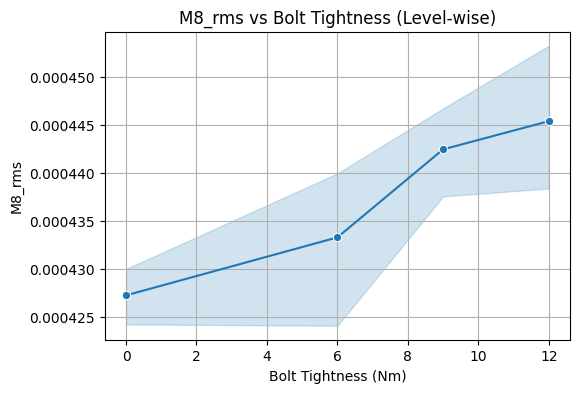

In [77]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=df1,
    x="Bolt_Nm",
    y="M6_max",
    marker="o"
)

plt.title(f"{col} vs Bolt Tightness (Level-wise)")
plt.xlabel("Bolt Tightness (Nm)")
plt.ylabel(col)
plt.grid()

plt.show()

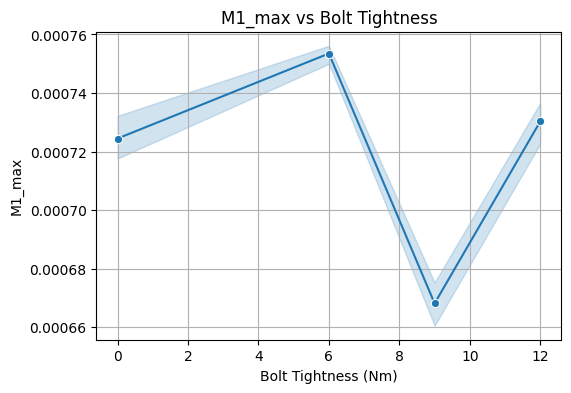

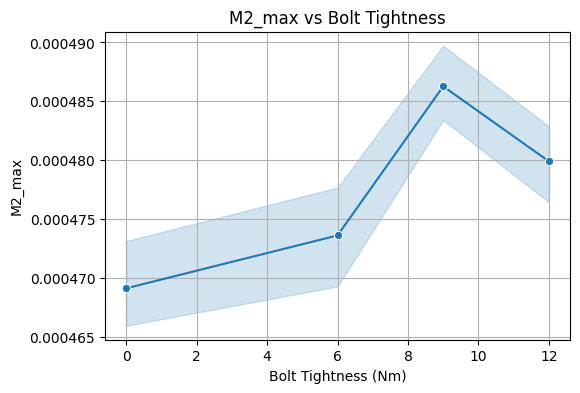

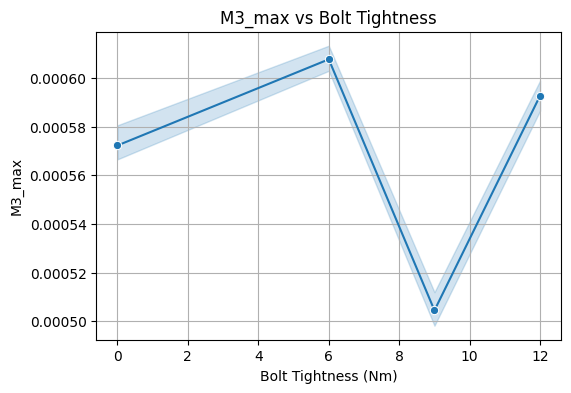

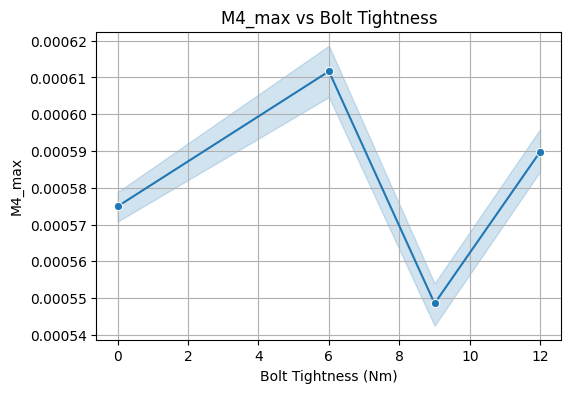

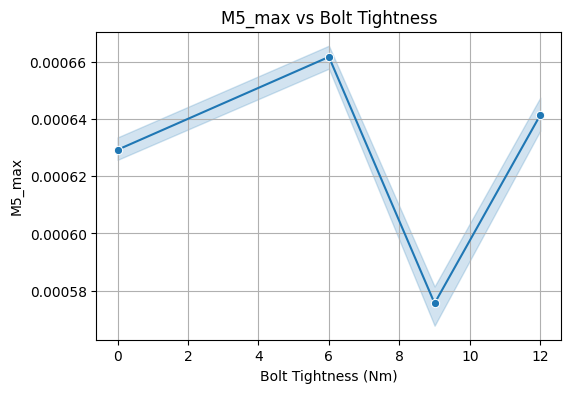

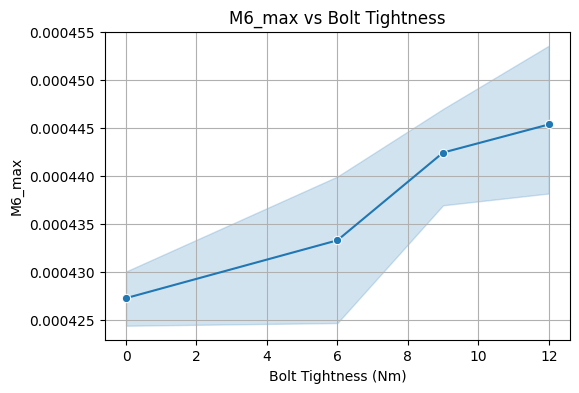

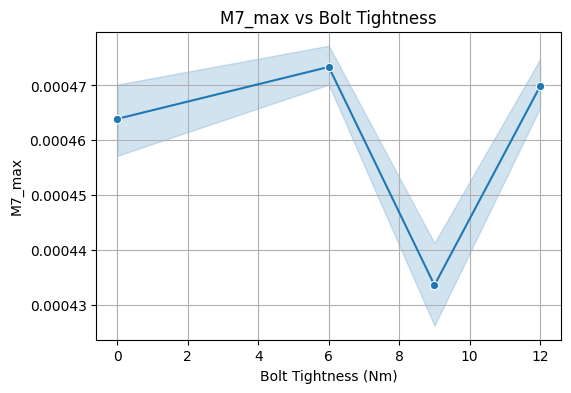

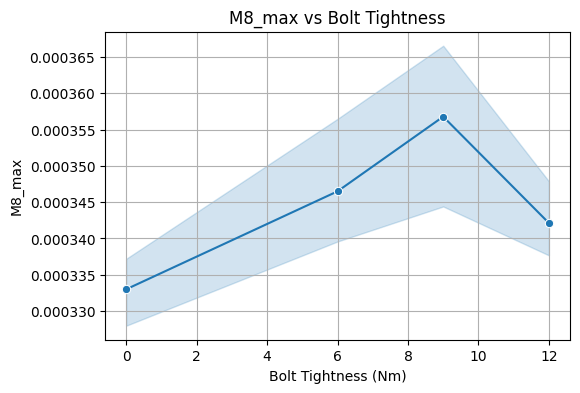

In [80]:
# Loop through 8 sensors
for i in range(1, 9):
    col = f"M{i}_max"   # change to _rms, _std if needed

    plt.figure(figsize=(6,4))

    sns.lineplot(
        data=df1,
        x="Bolt_Nm",
        y=col,
        marker="o"
    )

    plt.title(f"{col} vs Bolt Tightness")
    plt.xlabel("Bolt Tightness (Nm)")
    plt.ylabel(col)
    plt.grid()

    plt.show()

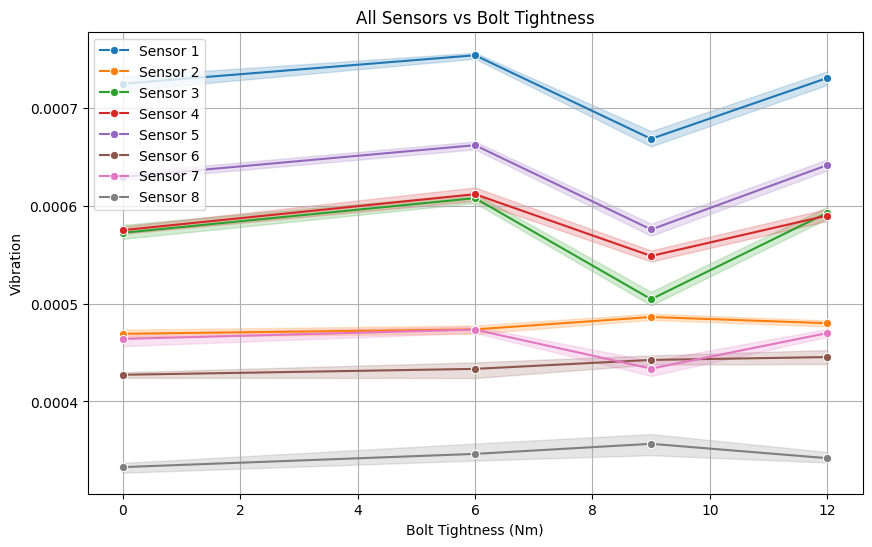

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for i in range(1, 9):
    col = f"M{i}_max"   # or M{i}_rms (recommended)

    sns.lineplot(
        data=df1,
        x="Bolt_Nm",
        y=col,
        marker="o",
        label=f"Sensor {i}"
    )

plt.title("All Sensors vs Bolt Tightness")
plt.xlabel("Bolt Tightness (Nm)")
plt.ylabel("Vibration")
plt.grid()
plt.legend()

plt.show()